In [1]:
import os
import pandas as pd
import numpy as np
import sys
from pathlib import Path

repo_root = !git rev-parse --show-toplevel
repo_root = repo_root[0]
os.chdir(repo_root)

# Input structure
input_dir = Path("data/input")
input_pdb = input_dir / "8RQC_AB.pdb"
receptor_ligand_chains = ["A"]
binder_chains = ["B"]
receptor_ligand_pdb = input_dir / "8RQC_AB.pdb"


# Search results
results_dir = Path("data/8RQC/search_results/8RQC_B_A")
postprocess_dir = Path("data/8RQC/postprocess")

# Path to postprocessed csv
postprocess_csv_path = Path("data/8RQC/8RQC_B_A_mimicry_postprocessed.csv")

# Path to uniprot_to_exclude_csv
uniprot_to_exclude_csv = "/work/upthomae/Meng/uniprot_to_exclude_17of23_251015.csv"

# Add source dir to path
source_dir = os.path.join(repo_root, "source")
sys.path.append(source_dir)


In [2]:
# Load all postprocess CSVs into a single DataFrame
df_postprocess = pd.DataFrame()
for file in os.listdir(postprocess_dir):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(postprocess_dir, file))
        df_postprocess = pd.concat([df_postprocess, df])

print(f"df_postprocess.shape {df_postprocess.shape}")

df_postprocess.shape (14701, 86)


In [3]:
pd.set_option('display.max_rows', None)
df_postprocess.iloc[0]

P1_id                                                           O00370-F1-TED04_A
P2_id                                                                    8RQC_B_A
P1_source_ppi_id                                                               p1
P2_source_ppi_id                                                               p1
P1_source_site                                                               2490
P2_source_site                                                                135
P1_source_TMscore                                                         0.10983
P2_source_TMscore                                                         0.45888
P1_source_iface                                                          0.208928
P2_source_iface                                                          0.308103
MaSIF-score                                                              0.453409
flattened_transform             0.2789073440755741,0.2033126051951899,0.938549...
ca_clash        

In [4]:
# add domain_length column by counting the number of characters in domain_seq
df_postprocess['domain_length'] = df_postprocess['domain_seq'].apply(len)
df_postprocess.iloc[0]

P1_id                                                           O00370-F1-TED04_A
P2_id                                                                    8RQC_B_A
P1_source_ppi_id                                                               p1
P2_source_ppi_id                                                               p1
P1_source_site                                                               2490
P2_source_site                                                                135
P1_source_TMscore                                                         0.10983
P2_source_TMscore                                                         0.45888
P1_source_iface                                                          0.208928
P2_source_iface                                                          0.308103
MaSIF-score                                                              0.453409
flattened_transform             0.2789073440755741,0.2033126051951899,0.938549...
ca_clash        

In [5]:
# Filter by uniprot_to_exclude_csv
df_uniprot_to_exclude = pd.read_csv(uniprot_to_exclude_csv)
uniprot_to_exclude = df_uniprot_to_exclude[df_uniprot_to_exclude['uniprot_excluded'] == 1]['uniprot_accn'].tolist()
n_row_before = len(df_postprocess)
df_postprocess = df_postprocess[~df_postprocess['uniprot_accn'].isin(uniprot_to_exclude)]
n_row_after = len(df_postprocess)
print(f"Filtered by uniprot_to_exclude:")
print(f"n_row_before: {n_row_before}, n_row_after: {n_row_after}")

Filtered by uniprot_to_exclude:
n_row_before: 14701, n_row_after: 14635


In [6]:
# Write to postprocess_csv_path
df_postprocess.to_csv(postprocess_csv_path, index=False)

In [7]:
# Read cphalo data
df_cphalo = pd.read_csv("/scratch/ymeng/masif_seed_mimicry/masif_mimicry/data/mezigdomide_scores.csv")
# remove Uniprot_ID column
df_cphalo = df_cphalo.drop(columns=['Uniprot_ID'])
# remove rows where hgnc_symbol is empty
df_cphalo = df_cphalo[df_cphalo['hgnc_symbol'].notna()]

# merge with df_uniprot_gene_name_mapping on hgnc_symbol/gene_name
df_uniprot_gene_name_mapping = pd.read_csv("/work/upthomae/Meng/human_ref_proteome_uniprot_genename_mapping.csv")
df_cphalo = df_cphalo.merge(df_uniprot_gene_name_mapping, left_on='hgnc_symbol', right_on='gene_name', how='left')

df_cphalo.to_csv("data/8RQC/mezigdomide_scores_w_uniprot.csv", index=False)
df_cphalo.head()

,contig_id,hgnc_symbol,internal_id,orf_pool,mezigdomide_enrichment_log2FC,dmso_enrichment_log2FC,mezi_priority_score,bfp_mean_log2cpm,bfp_max_log2cpm,bfp_abundance_percentile,bfp_adjusted_priority_score,mezi_priority_rank,bfp_adjusted_priority_rank,uniprot_id,gene_name,recommendedName
0,ORF18782|IID=3652|HGNC=ZNF692,ZNF692,3652.0,hORF81 125-128,3.744940,-1.817152,3.744940,4.142681,7.224961,82.447061,3.744940,1,1,Q9BU19,ZNF692,Zinc finger protein 692
1,ORF14053|IID=5023|HGNC=RTBDN,RTBDN,5023.0,hORF81 41-44,3.531717,-0.467845,3.531717,7.593669,8.422879,91.083593,3.531717,2,2,Q9BSG5,RTBDN,Retbindin
2,ORF10528|IID=9925|HGNC=NGB,NGB,9925.0,hORF81 101-104,3.760248,1.027652,3.364509,6.834095,10.145373,98.336590,3.364509,3,3,Q9NPG2,NGB,Neuroglobin
3,ORF01456|IID=9084|HGNC=BARX1,BARX1,9084.0,hORF81 05-08,3.198623,-0.977919,3.198623,8.254539,10.226409,98.484448,3.198623,4,4,Q9HBU1,BARX1,Homeobox protein BarH-like 1
4,ORF18511|IID=9766|HGNC=ZNF276,ZNF276,9766.0,hORF81 69-72,3.194037,-0.996160,3.194037,3.636801,5.395242,66.958864,3.194037,5,5,Q8N554,ZNF276,Zinc finger protein 276


In [140]:
import json

# Coherence score: geometric mean of rescaled descriptor quality, target coverage,
# and saturated cluster reproducibility (see pipeline discussion).
MASIF_SCORE_CUTOFF = 0.45  # DESC_DIST_SCORE_CUTOFF in mimicry_pipeline.config.sh
COHERENCE_TAU = 20.0
COHERENCE_W_Q, COHERENCE_W_C, COHERENCE_W_R = 0.8, 0.2, 0.4

with open(results_dir / "target_sites.json") as f:
    n_query_sites = json.load(f)["num_points"]

masif = pd.to_numeric(df_postprocess["MaSIF-score"], errors="coerce")
n_p2 = pd.to_numeric(df_postprocess["n_P2_source_site"], errors="coerce")
cluster_size = pd.to_numeric(df_postprocess["cluster_size"], errors="coerce")

q = np.clip((masif - MASIF_SCORE_CUTOFF) / (1.0 - MASIF_SCORE_CUTOFF), 0.0, 1.0)
c = np.clip(n_p2 / n_query_sites, 0.0, 1.0)
r = 1.0 - np.exp(-cluster_size / COHERENCE_TAU)

df_postprocess["coherence_score"] = (
    np.power(q, COHERENCE_W_Q)
    * np.power(c, COHERENCE_W_C)
    * np.power(r, COHERENCE_W_R)
)

df_postprocess[["MaSIF-score", "n_P2_source_site", "cluster_size", "coherence_score"]].describe()

,MaSIF-score,n_P2_source_site,cluster_size,coherence_score
count,14635.000000,14635.000000,14635.000000,14635.000000
mean,0.489680,5.547250,36.946703,0.085796
std,0.041955,4.275932,56.489206,0.099133
min,0.450002,1.000000,1.000000,0.000007
25%,0.461554,2.000000,3.000000,0.013195
50%,0.477608,4.000000,12.000000,0.049846
75%,0.502796,9.000000,44.000000,0.125061
max,0.880822,15.000000,452.000000,0.822523


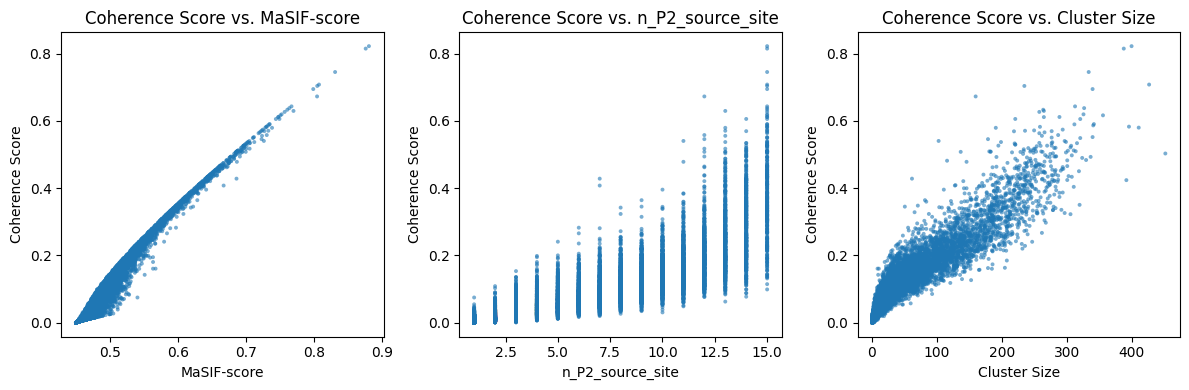

In [141]:
# Plot coherence_score ~ MaSIF-score, n_P2_source_site, cluster_size respectively in a 3-panel plot
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

scatter_args = dict(s=8, alpha=0.6, edgecolor='none')

# 1st panel: coherence_score vs. MaSIF-score
axes[0].scatter(df_postprocess["MaSIF-score"], df_postprocess["coherence_score"], **scatter_args)
axes[0].set_xlabel("MaSIF-score")
axes[0].set_ylabel("Coherence Score")
axes[0].set_title("Coherence Score vs. MaSIF-score")

# 2nd panel: coherence_score vs. n_P2_source_site
axes[1].scatter(df_postprocess["n_P2_source_site"], df_postprocess["coherence_score"], **scatter_args)
axes[1].set_xlabel("n_P2_source_site")
axes[1].set_ylabel("Coherence Score")
axes[1].set_title("Coherence Score vs. n_P2_source_site")

# 3rd panel: coherence_score vs. cluster_size
axes[2].scatter(df_postprocess["cluster_size"], df_postprocess["coherence_score"], **scatter_args)
axes[2].set_xlabel("Cluster Size")
axes[2].set_ylabel("Coherence Score")
axes[2].set_title("Coherence Score vs. Cluster Size")

plt.tight_layout()
plt.show()

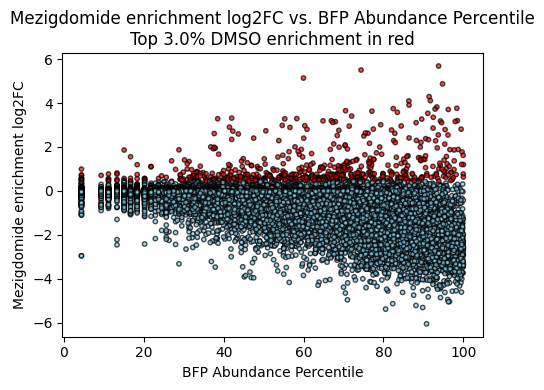

top_percentile_uniprot_ids: 567


In [142]:
import matplotlib.pyplot as plt
import numpy as np

percentile_enrichment_cutoff = 0.03

# Sort df_cphalo by the 'mezigdomide_enrichment_log2FC' percentile
dmso_sorted = df_cphalo.sort_values('mezigdomide_enrichment_log2FC', ascending=False).reset_index(drop=True)

# Calculate the threshold value for the top X%
cutoff_value = dmso_sorted['mezigdomide_enrichment_log2FC'].quantile(1 - percentile_enrichment_cutoff)

# Assign colors: red for top X% by mezigdomide_enrichment_log2FC, skyblue otherwise
colors = np.where(
    df_cphalo['mezigdomide_enrichment_log2FC'] >= cutoff_value, 
    'red', 
    'skyblue'
)

plt.figure(figsize=(5, 4))
plt.scatter(
    df_cphalo['bfp_abundance_percentile'],
    df_cphalo['mezigdomide_enrichment_log2FC'],
    color=colors,
    edgecolor='black',
    s=10,
    alpha=0.7
)
plt.xlabel('BFP Abundance Percentile')
plt.ylabel('Mezigdomide enrichment log2FC')
plt.title(f'Mezigdomide enrichment log2FC vs. BFP Abundance Percentile\nTop {percentile_enrichment_cutoff*100}% DMSO enrichment in red')
plt.tight_layout()
plt.show()

# Return the Uniprot_ID of the red data points as an array of strings
top_percentile_uniprot_ids = df_cphalo.loc[
    df_cphalo['mezigdomide_enrichment_log2FC'] >= cutoff_value, 'uniprot_id'
].astype(str).tolist()
print(f"top_percentile_uniprot_ids: {len(top_percentile_uniprot_ids)}")

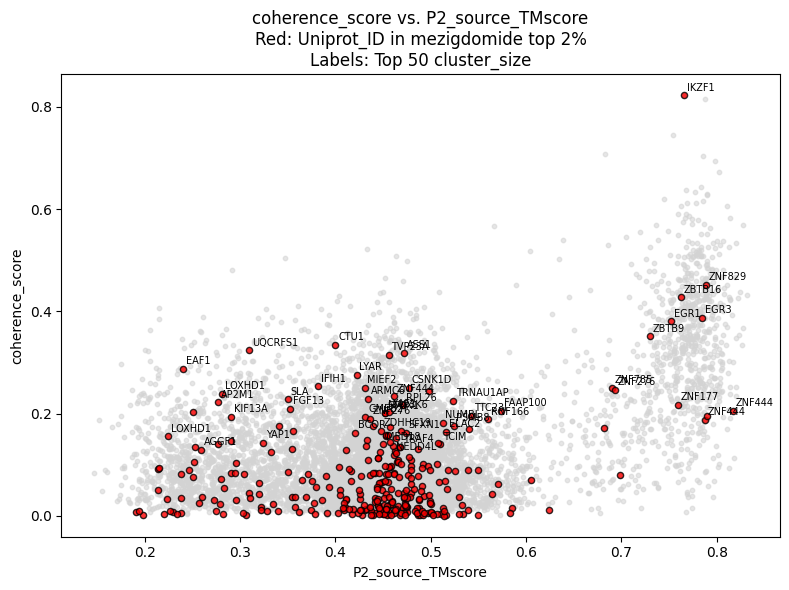

In [143]:
# Plot MaSIF-score ~ P2_source_TMscore, grey all, red highlight top
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df_postprocess[df_postprocess['n_P2_source_site'] > 2].copy()

# Use variable column names
x_axis_col = 'P2_source_TMscore'
y_axis_col = 'coherence_score'

fig, ax = plt.subplots(figsize=(8, 6))
# Plot all points in grey
ax.scatter(
    df_filtered[x_axis_col],
    df_filtered[y_axis_col],
    color='lightgrey',
    s=10,
    alpha=0.57,
    label='_nolegend_'
)

# Overlay: highlighted points from everywhere in postprocess that are in top_percentile_uniprot_ids
highlight_df = df_postprocess[df_postprocess["uniprot_accn"].astype(str).isin(top_percentile_uniprot_ids)]
highlight_scatter = ax.scatter(
    highlight_df[x_axis_col],
    highlight_df[y_axis_col],
    color='red',
    edgecolor='black',
    s=20,
    alpha=0.8,
    label="Top 2% enrichment"
)

# Label the red points with the top 50 highest cluster_size with their corresponding gene_name
# Merge gene_name if not present
if "gene_name" not in highlight_df.columns:
    highlight_df = highlight_df.merge(
        df_cphalo[["uniprot_id", "gene_name"]],
        left_on="uniprot_accn",
        right_on="uniprot_id",
        how="left"
    )

highlight_top50 = highlight_df.nlargest(50, "cluster_size").copy()

for _, row in highlight_top50.iterrows():
    x = row[x_axis_col]
    y = row[y_axis_col]
    gene_name = row.get("gene_name", None)
    if pd.isnull(gene_name):
        gene_name = ""
    else:
        gene_name = str(gene_name)
    if gene_name:
        ax.annotate(
            gene_name, 
            (x, y), 
            textcoords="offset points", 
            xytext=(2, 2),
            fontsize=7,
            color='black',
            ha='left',
            va='bottom'
        )

ax.set_xlabel(x_axis_col)
ax.set_ylabel(y_axis_col)
ax.set_title(f'{y_axis_col} vs. {x_axis_col}\nRed: Uniprot_ID in mezigdomide top 2%\nLabels: Top 50 cluster_size')
plt.tight_layout()
plt.show()

top_percentile_uniprot_ids: 567


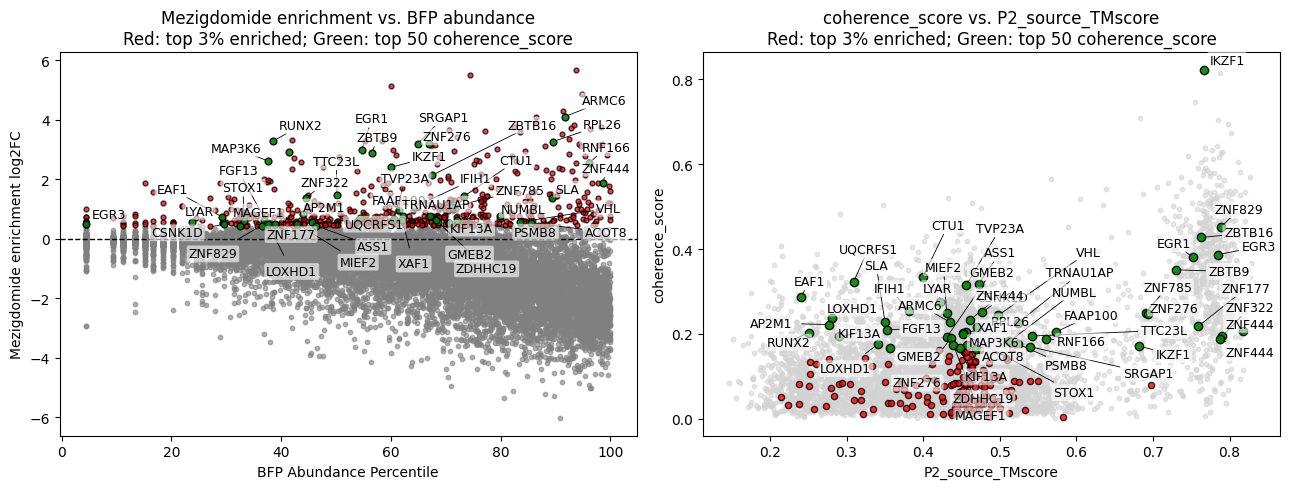

In [144]:
import matplotlib.pyplot as plt
import numpy as np

percentile_enrichment_cutoff = 0.03
x_axis_col = "P2_source_TMscore"
y_axis_col = "coherence_score"
out_csv = "data/8RQC/8RQC_cpHalo_top50_coherence_score_overlap.csv"

# Top 3% mezigdomide-enriched UniProt IDs (from cphalo screen)
cutoff_value = df_cphalo["mezigdomide_enrichment_log2FC"].quantile(
    1 - percentile_enrichment_cutoff
)
top_percentile_uniprot_ids = (
    df_cphalo.loc[
        df_cphalo["mezigdomide_enrichment_log2FC"] >= cutoff_value, "uniprot_id"
    ]
    .astype(str)
    .tolist()
)
print(f"top_percentile_uniprot_ids: {len(top_percentile_uniprot_ids)}")

# Top 50 coherence_score hits among enriched postprocess rows
highlight_post = df_postprocess[
    df_postprocess["uniprot_accn"].astype(str).isin(top_percentile_uniprot_ids)
].copy()
if "gene_name" not in highlight_post.columns:
    highlight_post = highlight_post.merge(
        df_cphalo[["uniprot_id", "gene_name"]].drop_duplicates("uniprot_id"),
        left_on="uniprot_accn",
        right_on="uniprot_id",
        how="left",
    )
top50_coherence = highlight_post.nlargest(50, y_axis_col).copy()
top50_uniprot_ids = set(top50_coherence["uniprot_accn"].astype(str))

df_cphalo_top50 = df_cphalo[df_cphalo["uniprot_id"].astype(str).isin(top50_uniprot_ids)]
df_cphalo_top50.to_csv(out_csv, index=False)

gene_lookup = (
    df_cphalo[["uniprot_id", "gene_name"]]
    .drop_duplicates("uniprot_id")
    .set_index("uniprot_id")["gene_name"]
    .astype(str)
)

def annotate_gene_names(ax, rows, x_col, y_col):
    from adjustText import adjust_text
    texts = []
    for _, row in rows.iterrows():
        gene_name = row.get("gene_name")
        if pd.isna(gene_name) or not str(gene_name).strip():
            continue
        t = ax.text(
            row[x_col],
            row[y_col],
            str(gene_name),
            fontsize=9,
            color="black",
            ha="left",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                alpha=0.6,
                edgecolor="none",
            ),
        )
        texts.append(t)
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="black", lw=0.6),
        expand=(1.2, 1.4),
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: mezigdomide enrichment vs BFP abundance ---
ax1 = axes[0]
is_enriched = df_cphalo["mezigdomide_enrichment_log2FC"] >= cutoff_value
is_top50_cphalo = is_enriched & df_cphalo["uniprot_id"].astype(str).isin(top50_uniprot_ids)

ax1.scatter(
    df_cphalo.loc[~is_enriched, "bfp_abundance_percentile"],
    df_cphalo.loc[~is_enriched, "mezigdomide_enrichment_log2FC"],
    color="grey",
    s=10,
    alpha=0.6,
)
ax1.scatter(
    df_cphalo.loc[is_enriched & ~is_top50_cphalo, "bfp_abundance_percentile"],
    df_cphalo.loc[is_enriched & ~is_top50_cphalo, "mezigdomide_enrichment_log2FC"],
    color="red",
    edgecolor="black",
    s=12,
    alpha=0.75,
)
ax1.scatter(
    df_cphalo.loc[is_top50_cphalo, "bfp_abundance_percentile"],
    df_cphalo.loc[is_top50_cphalo, "mezigdomide_enrichment_log2FC"],
    color="green",
    edgecolor="black",
    s=24,
    alpha=0.9,
    zorder=3,
)
ax1.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax1.set_xlabel("BFP Abundance Percentile")
ax1.set_ylabel("Mezigdomide enrichment log2FC")
ax1.set_title(
    f"Mezigdomide enrichment vs. BFP abundance\n"
    f"Red: top {percentile_enrichment_cutoff*100:.0f}% enriched; "
    f"Green: top 50 {y_axis_col}"
)

# Label top-50 coherence hits on cphalo panel (one point per UniProt)
top50_cphalo_labels = []
for uniprot_id in top50_uniprot_ids:
    cphalo_hits = df_cphalo[df_cphalo["uniprot_id"].astype(str) == uniprot_id]
    if cphalo_hits.empty:
        continue
    best_row = cphalo_hits.loc[cphalo_hits["mezigdomide_enrichment_log2FC"].idxmax()].copy()
    best_row["gene_name"] = gene_lookup.get(uniprot_id, "")
    top50_cphalo_labels.append(best_row)
if top50_cphalo_labels:
    annotate_gene_names(
        ax1,
        pd.DataFrame(top50_cphalo_labels),
        "bfp_abundance_percentile",
        "mezigdomide_enrichment_log2FC",
    )

# --- Panel 2: coherence_score vs P2_source_TMscore ---
df_filtered = df_postprocess[df_postprocess["n_P2_source_site"] > 2].copy()
ax2 = axes[1]
is_enriched_post = df_filtered["uniprot_accn"].astype(str).isin(top_percentile_uniprot_ids)
is_top50_post = df_filtered["uniprot_accn"].astype(str).isin(top50_uniprot_ids)

ax2.scatter(
    df_filtered.loc[~is_enriched_post, x_axis_col],
    df_filtered.loc[~is_enriched_post, y_axis_col],
    color="lightgrey",
    s=10,
    alpha=0.57,
)
ax2.scatter(
    df_filtered.loc[is_enriched_post & ~is_top50_post, x_axis_col],
    df_filtered.loc[is_enriched_post & ~is_top50_post, y_axis_col],
    color="red",
    edgecolor="black",
    s=20,
    alpha=0.8,
)
ax2.scatter(
    top50_coherence[x_axis_col],
    top50_coherence[y_axis_col],
    color="green",
    edgecolor="black",
    s=36,
    alpha=0.9,
    zorder=3,
)
annotate_gene_names(ax2, top50_coherence, x_axis_col, y_axis_col)

ax2.set_xlabel(x_axis_col)
ax2.set_ylabel(y_axis_col)
ax2.set_title(
    f"{y_axis_col} vs. {x_axis_col}\n"
    f"Red: top {percentile_enrichment_cutoff*100:.0f}% enriched; "
    f"Green: top 50 {y_axis_col}"
)

plt.tight_layout()
plt.show()

top_percentile_uniprot_ids: 567


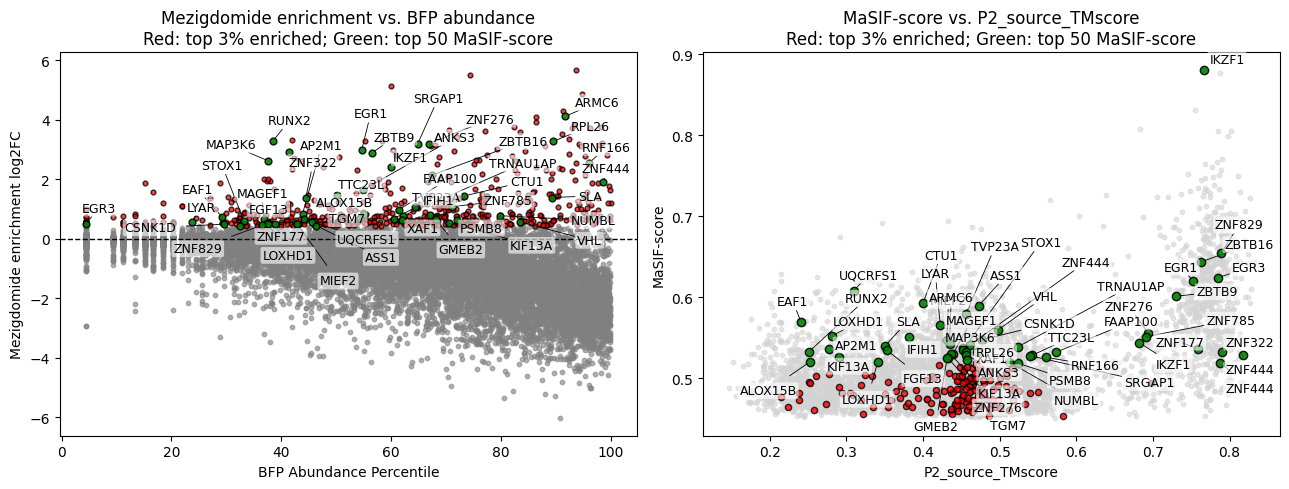

In [145]:
import matplotlib.pyplot as plt
import numpy as np

percentile_enrichment_cutoff = 0.03
x_axis_col = "P2_source_TMscore"
y_axis_col = "MaSIF-score"
out_csv = "data/8RQC/8RQC_cpHalo_top50_MaSIF-score_overlap.csv"

# Top 3% mezigdomide-enriched UniProt IDs (from cphalo screen)
cutoff_value = df_cphalo["mezigdomide_enrichment_log2FC"].quantile(
    1 - percentile_enrichment_cutoff
)
top_percentile_uniprot_ids = (
    df_cphalo.loc[
        df_cphalo["mezigdomide_enrichment_log2FC"] >= cutoff_value, "uniprot_id"
    ]
    .astype(str)
    .tolist()
)
print(f"top_percentile_uniprot_ids: {len(top_percentile_uniprot_ids)}")

# Top 50 coherence_score hits among enriched postprocess rows
highlight_post = df_postprocess[
    df_postprocess["uniprot_accn"].astype(str).isin(top_percentile_uniprot_ids)
].copy()
if "gene_name" not in highlight_post.columns:
    highlight_post = highlight_post.merge(
        df_cphalo[["uniprot_id", "gene_name"]].drop_duplicates("uniprot_id"),
        left_on="uniprot_accn",
        right_on="uniprot_id",
        how="left",
    )
top50_coherence = highlight_post.nlargest(50, y_axis_col).copy()
top50_uniprot_ids = set(top50_coherence["uniprot_accn"].astype(str))

df_cphalo_top50 = df_cphalo[df_cphalo["uniprot_id"].astype(str).isin(top50_uniprot_ids)]
df_cphalo_top50.to_csv(out_csv, index=False)

gene_lookup = (
    df_cphalo[["uniprot_id", "gene_name"]]
    .drop_duplicates("uniprot_id")
    .set_index("uniprot_id")["gene_name"]
    .astype(str)
)

def annotate_gene_names(ax, rows, x_col, y_col):
    from adjustText import adjust_text
    texts = []
    for _, row in rows.iterrows():
        gene_name = row.get("gene_name")
        if pd.isna(gene_name) or not str(gene_name).strip():
            continue
        t = ax.text(
            row[x_col],
            row[y_col],
            str(gene_name),
            fontsize=9,
            color="black",
            ha="left",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                alpha=0.6,
                edgecolor="none",
            ),
        )
        texts.append(t)
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="black", lw=0.6),
        expand=(1.2, 1.4),
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: mezigdomide enrichment vs BFP abundance ---
ax1 = axes[0]
is_enriched = df_cphalo["mezigdomide_enrichment_log2FC"] >= cutoff_value
is_top50_cphalo = is_enriched & df_cphalo["uniprot_id"].astype(str).isin(top50_uniprot_ids)

ax1.scatter(
    df_cphalo.loc[~is_enriched, "bfp_abundance_percentile"],
    df_cphalo.loc[~is_enriched, "mezigdomide_enrichment_log2FC"],
    color="grey",
    s=10,
    alpha=0.6,
)
ax1.scatter(
    df_cphalo.loc[is_enriched & ~is_top50_cphalo, "bfp_abundance_percentile"],
    df_cphalo.loc[is_enriched & ~is_top50_cphalo, "mezigdomide_enrichment_log2FC"],
    color="red",
    edgecolor="black",
    s=12,
    alpha=0.75,
)
ax1.scatter(
    df_cphalo.loc[is_top50_cphalo, "bfp_abundance_percentile"],
    df_cphalo.loc[is_top50_cphalo, "mezigdomide_enrichment_log2FC"],
    color="green",
    edgecolor="black",
    s=24,
    alpha=0.9,
    zorder=3,
)
ax1.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax1.set_xlabel("BFP Abundance Percentile")
ax1.set_ylabel("Mezigdomide enrichment log2FC")
ax1.set_title(
    f"Mezigdomide enrichment vs. BFP abundance\n"
    f"Red: top {percentile_enrichment_cutoff*100:.0f}% enriched; "
    f"Green: top 50 {y_axis_col}"
)

# Label top-50 coherence hits on cphalo panel (one point per UniProt)
top50_cphalo_labels = []
for uniprot_id in top50_uniprot_ids:
    cphalo_hits = df_cphalo[df_cphalo["uniprot_id"].astype(str) == uniprot_id]
    if cphalo_hits.empty:
        continue
    best_row = cphalo_hits.loc[cphalo_hits["mezigdomide_enrichment_log2FC"].idxmax()].copy()
    best_row["gene_name"] = gene_lookup.get(uniprot_id, "")
    top50_cphalo_labels.append(best_row)
if top50_cphalo_labels:
    annotate_gene_names(
        ax1,
        pd.DataFrame(top50_cphalo_labels),
        "bfp_abundance_percentile",
        "mezigdomide_enrichment_log2FC",
    )

# --- Panel 2: coherence_score vs P2_source_TMscore ---
df_filtered = df_postprocess[df_postprocess["n_P2_source_site"] > 2].copy()
ax2 = axes[1]
is_enriched_post = df_filtered["uniprot_accn"].astype(str).isin(top_percentile_uniprot_ids)
is_top50_post = df_filtered["uniprot_accn"].astype(str).isin(top50_uniprot_ids)

ax2.scatter(
    df_filtered.loc[~is_enriched_post, x_axis_col],
    df_filtered.loc[~is_enriched_post, y_axis_col],
    color="lightgrey",
    s=10,
    alpha=0.57,
)
ax2.scatter(
    df_filtered.loc[is_enriched_post & ~is_top50_post, x_axis_col],
    df_filtered.loc[is_enriched_post & ~is_top50_post, y_axis_col],
    color="red",
    edgecolor="black",
    s=20,
    alpha=0.8,
)
ax2.scatter(
    top50_coherence[x_axis_col],
    top50_coherence[y_axis_col],
    color="green",
    edgecolor="black",
    s=36,
    alpha=0.9,
    zorder=3,
)
annotate_gene_names(ax2, top50_coherence, x_axis_col, y_axis_col)

ax2.set_xlabel(x_axis_col)
ax2.set_ylabel(y_axis_col)
ax2.set_title(
    f"{y_axis_col} vs. {x_axis_col}\n"
    f"Red: top {percentile_enrichment_cutoff*100:.0f}% enriched; "
    f"Green: top 50 {y_axis_col}"
)

plt.tight_layout()
plt.show()

top_percentile_uniprot_ids: 567


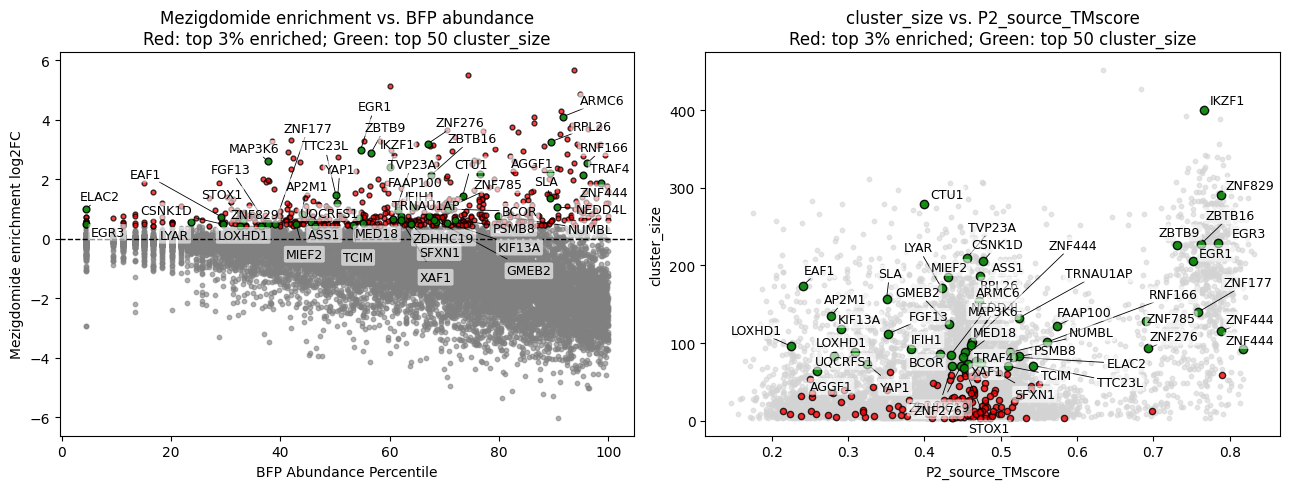

In [147]:
import matplotlib.pyplot as plt
import numpy as np

percentile_enrichment_cutoff = 0.03
x_axis_col = "P2_source_TMscore"
y_axis_col = "cluster_size"
out_csv = f"data/8RQC/8RQC_cpHalo_top50_{y_axis_col}_overlap.csv"

# Top 3% mezigdomide-enriched UniProt IDs (from cphalo screen)
cutoff_value = df_cphalo["mezigdomide_enrichment_log2FC"].quantile(
    1 - percentile_enrichment_cutoff
)
top_percentile_uniprot_ids = (
    df_cphalo.loc[
        df_cphalo["mezigdomide_enrichment_log2FC"] >= cutoff_value, "uniprot_id"
    ]
    .astype(str)
    .tolist()
)
print(f"top_percentile_uniprot_ids: {len(top_percentile_uniprot_ids)}")

# Top 50 coherence_score hits among enriched postprocess rows
highlight_post = df_postprocess[
    df_postprocess["uniprot_accn"].astype(str).isin(top_percentile_uniprot_ids)
].copy()
if "gene_name" not in highlight_post.columns:
    highlight_post = highlight_post.merge(
        df_cphalo[["uniprot_id", "gene_name"]].drop_duplicates("uniprot_id"),
        left_on="uniprot_accn",
        right_on="uniprot_id",
        how="left",
    )
top50_coherence = highlight_post.nlargest(50, y_axis_col).copy()
top50_uniprot_ids = set(top50_coherence["uniprot_accn"].astype(str))

df_cphalo_top50 = df_cphalo[df_cphalo["uniprot_id"].astype(str).isin(top50_uniprot_ids)]
df_cphalo_top50.to_csv(out_csv, index=False)

gene_lookup = (
    df_cphalo[["uniprot_id", "gene_name"]]
    .drop_duplicates("uniprot_id")
    .set_index("uniprot_id")["gene_name"]
    .astype(str)
)

def annotate_gene_names(ax, rows, x_col, y_col):
    from adjustText import adjust_text
    texts = []
    for _, row in rows.iterrows():
        gene_name = row.get("gene_name")
        if pd.isna(gene_name) or not str(gene_name).strip():
            continue
        t = ax.text(
            row[x_col],
            row[y_col],
            str(gene_name),
            fontsize=9,
            color="black",
            ha="left",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                alpha=0.6,
                edgecolor="none",
            ),
        )
        texts.append(t)
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="black", lw=0.6),
        expand=(1.2, 1.4),
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: mezigdomide enrichment vs BFP abundance ---
ax1 = axes[0]
is_enriched = df_cphalo["mezigdomide_enrichment_log2FC"] >= cutoff_value
is_top50_cphalo = is_enriched & df_cphalo["uniprot_id"].astype(str).isin(top50_uniprot_ids)

ax1.scatter(
    df_cphalo.loc[~is_enriched, "bfp_abundance_percentile"],
    df_cphalo.loc[~is_enriched, "mezigdomide_enrichment_log2FC"],
    color="grey",
    s=10,
    alpha=0.6,
)
ax1.scatter(
    df_cphalo.loc[is_enriched & ~is_top50_cphalo, "bfp_abundance_percentile"],
    df_cphalo.loc[is_enriched & ~is_top50_cphalo, "mezigdomide_enrichment_log2FC"],
    color="red",
    edgecolor="black",
    s=12,
    alpha=0.75,
)
ax1.scatter(
    df_cphalo.loc[is_top50_cphalo, "bfp_abundance_percentile"],
    df_cphalo.loc[is_top50_cphalo, "mezigdomide_enrichment_log2FC"],
    color="green",
    edgecolor="black",
    s=24,
    alpha=0.9,
    zorder=3,
)
ax1.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax1.set_xlabel("BFP Abundance Percentile")
ax1.set_ylabel("Mezigdomide enrichment log2FC")
ax1.set_title(
    f"Mezigdomide enrichment vs. BFP abundance\n"
    f"Red: top {percentile_enrichment_cutoff*100:.0f}% enriched; "
    f"Green: top 50 {y_axis_col}"
)

# Label top-50 coherence hits on cphalo panel (one point per UniProt)
top50_cphalo_labels = []
for uniprot_id in top50_uniprot_ids:
    cphalo_hits = df_cphalo[df_cphalo["uniprot_id"].astype(str) == uniprot_id]
    if cphalo_hits.empty:
        continue
    best_row = cphalo_hits.loc[cphalo_hits["mezigdomide_enrichment_log2FC"].idxmax()].copy()
    best_row["gene_name"] = gene_lookup.get(uniprot_id, "")
    top50_cphalo_labels.append(best_row)
if top50_cphalo_labels:
    annotate_gene_names(
        ax1,
        pd.DataFrame(top50_cphalo_labels),
        "bfp_abundance_percentile",
        "mezigdomide_enrichment_log2FC",
    )

# --- Panel 2: coherence_score vs P2_source_TMscore ---
df_filtered = df_postprocess[df_postprocess["n_P2_source_site"] > 2].copy()
ax2 = axes[1]
is_enriched_post = df_filtered["uniprot_accn"].astype(str).isin(top_percentile_uniprot_ids)
is_top50_post = df_filtered["uniprot_accn"].astype(str).isin(top50_uniprot_ids)

ax2.scatter(
    df_filtered.loc[~is_enriched_post, x_axis_col],
    df_filtered.loc[~is_enriched_post, y_axis_col],
    color="lightgrey",
    s=10,
    alpha=0.57,
)
ax2.scatter(
    df_filtered.loc[is_enriched_post & ~is_top50_post, x_axis_col],
    df_filtered.loc[is_enriched_post & ~is_top50_post, y_axis_col],
    color="red",
    edgecolor="black",
    s=20,
    alpha=0.8,
)
ax2.scatter(
    top50_coherence[x_axis_col],
    top50_coherence[y_axis_col],
    color="green",
    edgecolor="black",
    s=36,
    alpha=0.9,
    zorder=3,
)
annotate_gene_names(ax2, top50_coherence, x_axis_col, y_axis_col)

ax2.set_xlabel(x_axis_col)
ax2.set_ylabel(y_axis_col)
ax2.set_title(
    f"{y_axis_col} vs. {x_axis_col}\n"
    f"Red: top {percentile_enrichment_cutoff*100:.0f}% enriched; "
    f"Green: top 50 {y_axis_col}"
)

plt.tight_layout()
plt.show()

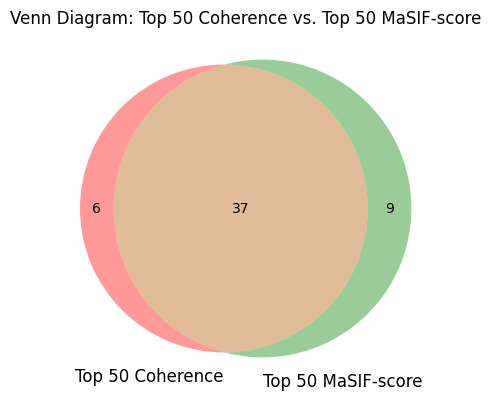

In [148]:
# Plot a Venn diagram to show overlap between top50_coherence and top50_MaSIF-score

import matplotlib.pyplot as plt
from matplotlib_venn import venn2

df_top50_coherence = pd.read_csv("data/8RQC/8RQC_cpHalo_top50_coherence_score_overlap.csv")
df_top50_MaSIF = pd.read_csv("data/8RQC/8RQC_cpHalo_top50_cluster_size_overlap.csv")

set_coherence = set(df_top50_coherence['uniprot_id'])
set_MaSIF = set(df_top50_MaSIF['uniprot_id'])

plt.figure(figsize=(5, 5))
venn2([set_coherence, set_MaSIF], set_labels=('Top 50 Coherence', 'Top 50 MaSIF-score'))
plt.title("Venn Diagram: Top 50 Coherence vs. Top 50 MaSIF-score")
plt.show()

___


In [41]:
from Bio.PDB import PDBIO, PDBParser, StructureBuilder
from Bio.PDB.Structure import Structure
from Bio.PDB.Model import Model

parser = PDBParser()
struct = parser.get_structure("021structure", input_pdb)

# create a new structure and model to hold selected chains
new_struct = Structure("receptor_ligand")
model = Model(0)
new_struct.add(model)

for chain_id in receptor_ligand_chains:
    chain = struct[0][chain_id]
    # Clone the chain to avoid problems when writing out
    import copy
    model.add(copy.deepcopy(chain))

io = PDBIO()
io.set_structure(new_struct)
io.save(receptor_ligand_pdb)

/home/ymeng/miniconda3/envs/MaSIF/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 6610
  warnings.warn(
